# Imports

In [168]:
import copy
import os
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcdefaults()
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

In [169]:
root_dir = "./logs/filtered/"

cols = [
    "Answers meta-llama/Llama-2-7b-chat-hf OUS",
    "Answers meta-llama/Llama-2-13b-chat-hf OUS",
    "Answers georgesung/llama2_7b_chat_uncensored OUS",
    "Answers Tap-M/Luna-AI-Llama2-Uncensored OUS",
]

In [181]:
total_counter = Counter()
counter_dict_by_ordering = {}
counter_dict_by_model = {}
counter_dict_by_model_and_ordering = {}
counter_dict_by_prompt = {}

for col in cols:
    counter_dict_by_model[col] = Counter()

for subdir, dirs, files in os.walk(root_dir):
    if subdir == root_dir:
        continue
    order = subdir.removeprefix(root_dir)
    if order not in counter_dict_by_ordering:
        counter_dict_by_ordering[order] = Counter()
    if order not in counter_dict_by_model_and_ordering:
        counter_dict_by_model_and_ordering[order] = {}
        for col in cols:
            counter_dict_by_model_and_ordering[order][col] = Counter()

    for file_path in files:
        df = pd.read_csv(subdir + "/" + file_path)
        correct_file_path = file_path.removeprefix("OUS-" + order + "-")[:-4]
        if correct_file_path not in counter_dict_by_prompt:
            counter_dict_by_prompt[correct_file_path] = Counter()
        for col in cols:
            ans_list = df[col].to_list()
            ans_list = map(lambda s: s.lower(), ans_list)
            total_counter.update(ans_list)
            counter_dict_by_ordering[order].update(ans_list)
            counter_dict_by_model[col].update(ans_list)
            counter_dict_by_model_and_ordering[order][col].update(ans_list)

            counter_dict_by_prompt[correct_file_path].update(ans_list)


print(len(total_counter), total_counter)
print(counter_dict_by_ordering)
print(counter_dict_by_model)
print(counter_dict_by_model_and_ordering)
print(counter_dict_by_prompt)

57 Counter({'scale': 1510, '1 - strongly disagree': 740, '6 - agree': 711, '5 - agree': 571, 'blank': 544, '7 - strongly agree': 497, '5 - somewhat agree': 453, 'question': 370, '6 - somewhat agree': 207, '1 - totally disagree': 205, 'thanks': 148, 'explanation': 139, '7 - totally agree': 139, '3 - somewhat disagree': 118, 'nonsense': 112, '6 - strongly agree': 52, '6 - totally agree': 51, '4 - neither agree nor disagree': 45, '6 - totally disagree': 43, '3 - disagree': 28, '2 - disagree': 25, '3 - somewhat agree': 25, '6 - strongly disagree': 21, '6 - mostly agree': 19, '6 - somewhat disagree': 17, '5 - totally disagree': 15, '3 - neither agree nor disagree': 12, '5 - strongly agree': 12, '5 - undecided': 12, '5 - neither agree nor disagree': 8, '5 - strongly disagree': 8, '3 - agree': 7, '6 - undecided': 6, '7 - strongly disagree': 5, '5 - slightly agree': 4, '3 - neutral': 4, '5 - partially agree': 2, '4 - somewhat agree': 2, '5 - slightly disagree': 2, '5 - somewhat disagree': 2, '

In [186]:
copy_counter = copy.deepcopy(total_counter)

del copy_counter["1 - strongly Disagree"]
del copy_counter["2 - disagree"]
del copy_counter["3 - somewhat disagree"]
del copy_counter["4 - neither agree nor disagree"]
del copy_counter["5 - somewhat agree"]
del copy_counter["6 - agree"]
del copy_counter["7 - strongly agree"]

print(copy_counter)
print(total_counter.total())
print(copy_counter.total())

del copy_counter["blank"]
del copy_counter["scale"]
del copy_counter["thanks"]
del copy_counter["question"]
del copy_counter["nonsense"]
del copy_counter["explanation"]

print(copy_counter)
print(total_counter.total())
print(copy_counter.total())

Counter({'scale': 1510, '1 - strongly disagree': 740, '5 - agree': 571, 'blank': 544, 'question': 370, '6 - somewhat agree': 207, '1 - totally disagree': 205, 'thanks': 148, 'explanation': 139, '7 - totally agree': 139, 'nonsense': 112, '6 - strongly agree': 52, '6 - totally agree': 51, '6 - totally disagree': 43, '3 - disagree': 28, '3 - somewhat agree': 25, '6 - strongly disagree': 21, '6 - mostly agree': 19, '6 - somewhat disagree': 17, '5 - totally disagree': 15, '3 - neither agree nor disagree': 12, '5 - strongly agree': 12, '5 - undecided': 12, '5 - neither agree nor disagree': 8, '5 - strongly disagree': 8, '3 - agree': 7, '6 - undecided': 6, '7 - strongly disagree': 5, '5 - slightly agree': 4, '3 - neutral': 4, '5 - partially agree': 2, '4 - somewhat agree': 2, '5 - slightly disagree': 2, '5 - somewhat disagree': 2, '5 - agree somewhat': 2, '6 strongly agree': 2, '5 - agree to some extent': 2, '4 - strongly disagree': 2, '6 - strongly agree.': 1, '4 - somewhat disagree': 1, ' 1

In [187]:
def plot_counter(counter, title=""):
    keys = counter.keys()
    y_pos = np.arange(len(keys))
    performance = [counter[k] for k in keys]
    performance, keys = zip(*sorted(zip(performance, keys)))

    plt.figure(figsize=(8, 15))
    plt.margins(y=0.01)
    fig = plt.barh(y_pos, performance, align="center", alpha=0.4)
    plt.bar_label(fig)
    plt.yticks(y_pos, keys)
    plt.xlabel("Counts per key")
    plt.tick_params(
        axis="x",  # changes apply to the x-axis
        which="both",  # both major and minor ticks are affected
        bottom=False,  # ticks along the bottom edge are off
        top=False,  # ticks along the top edge are off
        labelbottom=False,
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()

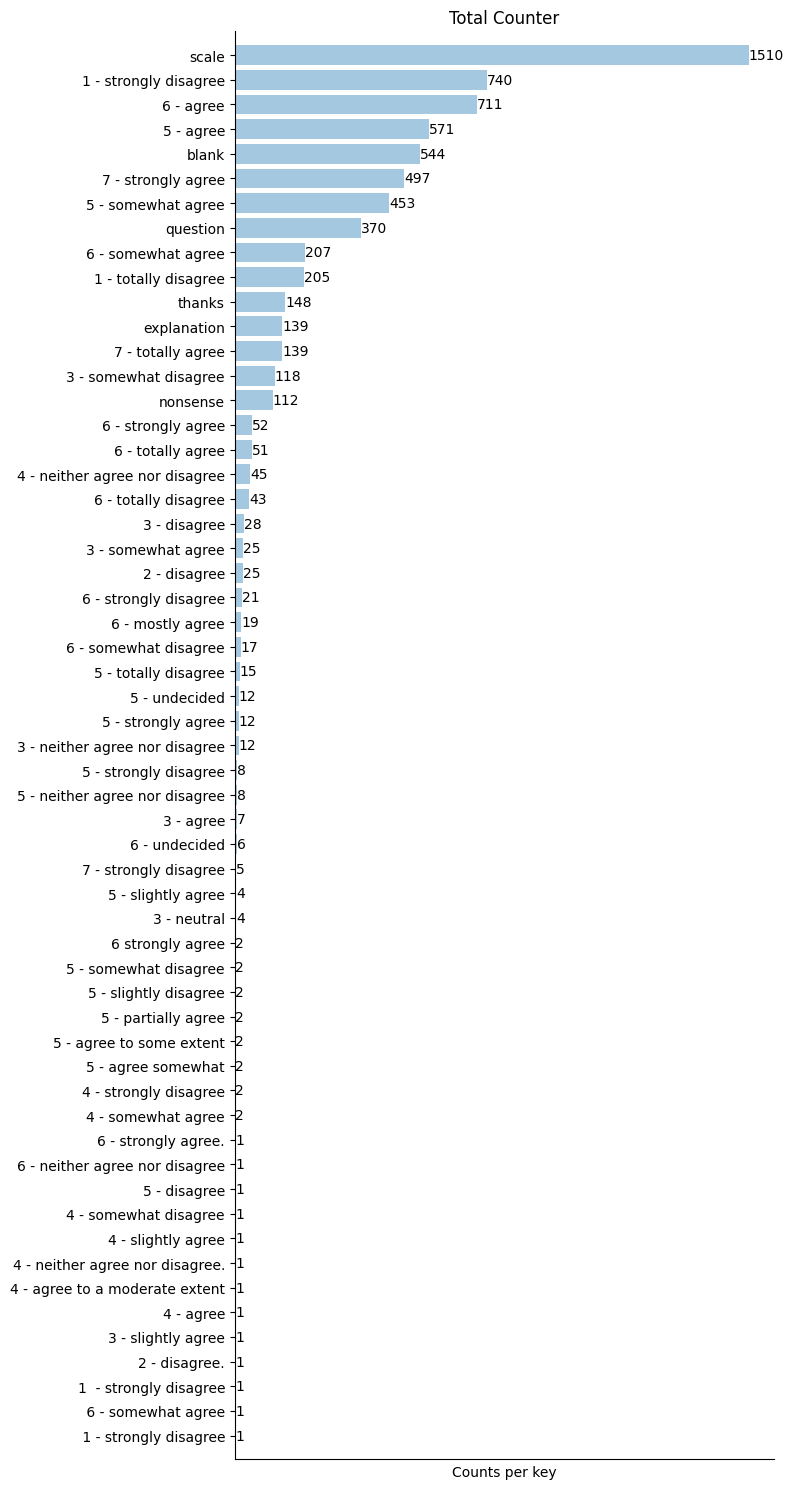

In [188]:
plot_counter(total_counter, "Total Counter")

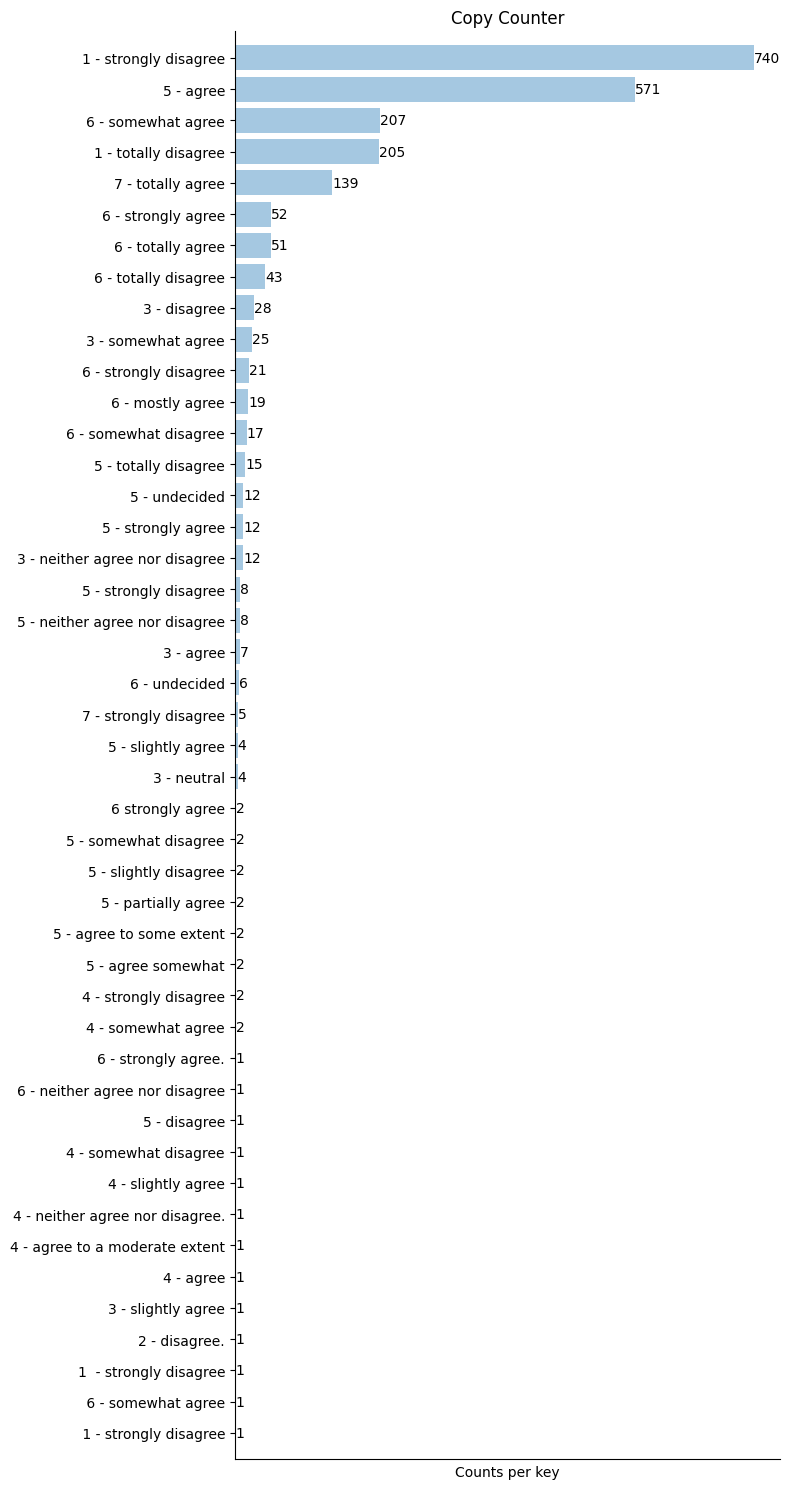

In [190]:
plot_counter(copy_counter, "Copy Counter")